In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

correct_datafile = "data/H2H2_collisions.csv"
incorrect_datafile = "data/H2H2_collisionsV2.npy"

def load_file(datafile):
    if ".npy" in datafile:
        data = np.load(datafile)
        data = pd.DataFrame(data, columns=["Etr", "Er1", "Er2", "Etrp", "Er1p", "Er2p"])
    elif ".csv" in datafile:
        data = pd.read_csv(datafile, header=0)
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .npy file.")
    return data

In [2]:
good_data = load_file(correct_datafile)
bad_data = load_file(incorrect_datafile)

fig, ax= plt.subplots(2, 2, figsize=(12, 12))
# Plot translational energy distribution
bins = np.linspace(0, max(good_data.iloc[:,0].max(), good_data.iloc[:,3].max()), 50)
Etr_init = good_data.iloc[:,0]
Etr_final = good_data.iloc[:,3]
ax[0,0].hist(Etr_init, bins=bins, alpha=0.5, label='Initial Translational Energy')
ax[0,0].hist(Etr_final, bins=bins, alpha=0.5, label='Final Translational Energy')
ax[0,0].set_xlabel('Translational temperature (K)')
ax[0,0].set_ylabel('Frequency')
ax[0,0].set_title('O2 Translational Energy distribution')
ax[0,0].legend()

# Plot rotational energy distribution
bins = np.linspace(0, max(good_data.iloc[:,1].max(), good_data.iloc[:,4].max()), 50)
Er1_init = good_data.iloc[:,1]
Er1_final = good_data.iloc[:,4]
ax[0,1].hist(Er1_init, bins=bins, alpha=0.5, label='Initial Rotational Energy')
ax[0,1].hist(Er1_final, bins=bins, alpha=0.5, label='Final Rotational Energy')
ax[0,1].set_xlabel('Rotational temperature (K)')
ax[0,1].set_ylabel('Frequency')
ax[0,1].set_title('O2 molecule 1 Rotational Energy distribution')
ax[0,1].legend()

# translational energy distribution
bins = np.linspace(0, max(bad_data.iloc[:,0].max(), bad_data.iloc[:,3].max()), 50)
Etr_init = bad_data.iloc[:,0]
Etr_final = bad_data.iloc[:,3]
ax[1,0].hist(Etr_init, bins=bins, alpha=0.5, label='Initial Translational Energy')
ax[1,0].hist(Etr_final, bins=bins, alpha=0.5, label='Final Translational Energy')
ax[1,0].set_xlabel('Translational temperature (K)')
ax[1,0].set_ylabel('Frequency')
ax[1,0].set_title('O2 Translational Energy distribution')
ax[1,0].legend()

bins = np.linspace(0, max(bad_data.iloc[:,2].max(), bad_data.iloc[:,5].max()), 50)
Er2_init = bad_data.iloc[:,2]
Er2_final = bad_data.iloc[:,5]
ax[1,1].hist(Er2_init, bins=bins, alpha=0.5, label='Initial Rotational Energy')
ax[1,1].hist(Er2_final, bins=bins, alpha=0.5, label='Final Rotational Energy')
ax[1,1].set_xlabel('Rotational temperature (K)')
ax[1,1].set_ylabel('Frequency')
ax[1,1].set_title('O2 molecule 2 Rotational Energy distribution')
ax[1,1].legend()

FileNotFoundError: [Errno 2] No such file or directory: 'data/H2H2_collisionsV2.npy'

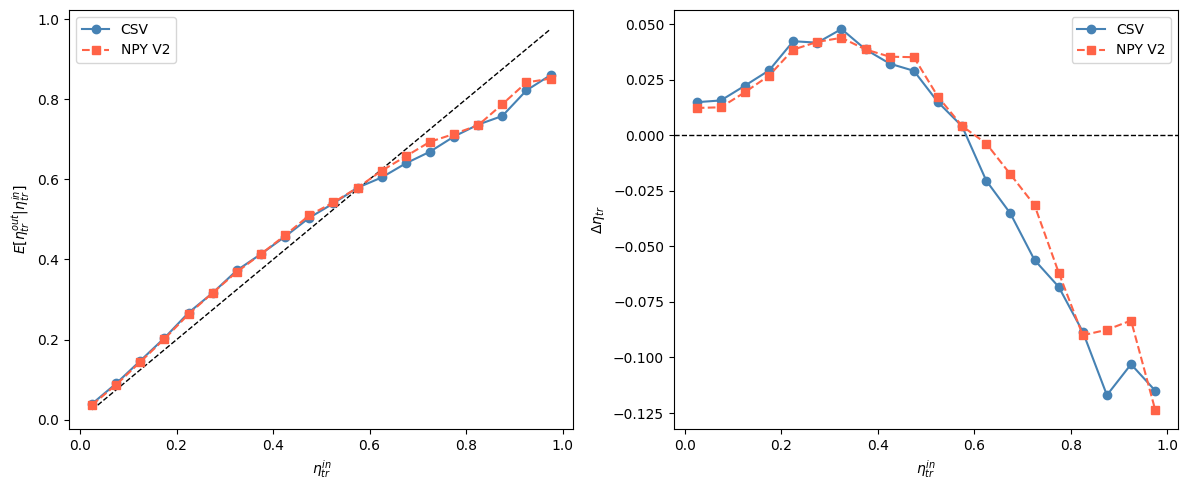

In [ ]:
def compute_eta(data):
    Etot  = data["Etr"] + data["Er1"] + data["Er2"]
    Etotp = data["Etrp"] + data["Er1p"] + data["Er2p"]
    valid = Etot > 0
    return (data["Etr"] / Etot)[valid].values, (data["Etrp"] / Etotp)[valid].values

edges = np.arange(0.0, 1.05, 0.05)
mids  = 0.5 * (edges[:-1] + edges[1:])

def conditional_means(eta_in, eta_out):
    means = np.full(len(mids), np.nan)
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (eta_in >= lo) & (eta_in < hi)
        if mask.sum() >= 5:
            means[i] = eta_out[mask].mean()
    return means

good_in, good_out = compute_eta(good_data)
bad_in,  bad_out  = compute_eta(bad_data)
good_means = conditional_means(good_in, good_out)
bad_means  = conditional_means(bad_in,  bad_out)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(mids, mids, "k--", lw=1)
ax.plot(mids, good_means, "o-",  color="steelblue", label="CSV")
ax.plot(mids, bad_means,  "s--", color="tomato",    label="NPY V2")
ax.set_xlabel(r"$\eta_{tr}^{in}$")
ax.set_ylabel(r"$E[\eta_{tr}^{out} | \eta_{tr}^{in}]$")
ax.legend()

ax = axes[1]
ax.axhline(0, color="k", lw=1, ls="--")
ax.plot(mids, good_means - mids, "o-",  color="steelblue", label="CSV")
ax.plot(mids, bad_means  - mids, "s--", color="tomato",    label="NPY V2")
ax.set_xlabel(r"$\eta_{tr}^{in}$")
ax.set_ylabel(r"$\Delta\eta_{tr}$")
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
import torch

correct_model_path = "results/models/mdn_H2H2.pth"
incorrect_model_path = "results/models/mdn_H2H2V2.pth"

correct_dict   = torch.load(correct_model_path,   map_location="cpu")
incorrect_dict = torch.load(incorrect_model_path, map_location="cpu")

keys = ["input_mean", "input_std", "output_mean", "output_std"]
labels = ["Etot", "eta_tr", "eta_rotA"]
out_labels = ["eta_tr_out", "eta_rotA_out"]

print(f"{'Parameter':<20} {'Dim':<12} {'Correct':>12} {'Wrong':>12} {'Diff':>12}")
print("-" * 70)
for key in keys:
    c = correct_dict[key].numpy()
    w = incorrect_dict[key].numpy()
    dim_labels = labels if "input" in key else out_labels
    for i, (cv, wv, lbl) in enumerate(zip(c, w, dim_labels)):
        name = f"{key}[{lbl}]"
        print(f"  {name:<18} {lbl:<12} {cv:>12.4f} {wv:>12.4f} {cv-wv:>+12.4f}")
    print()


Parameter            Dim               Correct        Wrong         Diff
----------------------------------------------------------------------
  input_mean[Etot]   Etot            6052.8550    6059.2222      -6.3672
  input_mean[eta_tr] eta_tr             0.4813       0.4741      +0.0072
  input_mean[eta_rotA] eta_rotA           0.5023       0.4959      +0.0063

  input_std[Etot]    Etot            2094.9902    2111.6736     -16.6833
  input_std[eta_tr]  eta_tr             0.1986       0.2036      -0.0050
  input_std[eta_rotA] eta_rotA           0.2399       0.2367      +0.0032

  output_mean[eta_tr_out] eta_tr_out         0.4860       0.4841      +0.0019
  output_mean[eta_rotA_out] eta_rotA_out       0.5027       0.5001      +0.0026

  output_std[eta_tr_out] eta_tr_out         0.2102       0.2152      -0.0050
  output_std[eta_rotA_out] eta_rotA_out       0.2525       0.2491      +0.0034

